# When Passengers Stop Flying: A Data-Driven Investigation into Airline Satisfaction
### Explanatory Data Analysis | M512A Data Visualisation & Communications
### Client: Airline Management Board 
### Name:- Om Dipak Patil 
### GH-Number:-GH1044372

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.offline as pyo
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')
pio.renderers.default = "notebook_connected"
print("Libraries loaded successfully.")

Libraries loaded successfully.


## Section 1: Context of Business and Visualisation

### For whom is this report intended — And What is our desired outcome?

The Chief operating Officer and Head of Customer Experience are the only senior airline management members for whom this notebook is intended. This report isn't scientific. Every graphic and story has been adjusted for those making decisions who require unambiguous proof rather tahn statistical analysis.  


### Business Problem

With only 43% of passengers leaving thrilled, the airline is experiencing a quantifiable crisis in customer satisfication. A 57% unhappiness percentage is not a functional annoyance in a low-switching-cost company where discontent spreads quickly online. Retaining revenue is directly threatened by it.

Traveller's dissatisfaction is not only issue. It's because the airline dosen't yet know where to invest to fix it most efficiently. The study provides a direct response to that query.

### Who Is the Audience?

Theb two main stakeholders on the airline's senior leadership team are the target audience for this report:

- **Head of Customer Experience (CX)** 

- **Chief Operating Officer (COO)** 

### Comparing Explanatory and Exploratory Analysis 

Finding the patterns is the goal of exploratory analysis. They are presented to an audience that must take action through explanatory analysis. The exploration phase is finished: This notebook is fully informative. The series of carefully chosen visuals that follows each convey a single, practical discovery that leads to three particular business recommendations.

### Chart Design Philosophy

Utilizing [datavizproject.com](https://datavizproject.com) as a guide, all chart kinds were chosen. The following design principles were used throughout: no chart trash, straightforward data labels on each ba, one highlight color with grey for context, and axes simplified to the bare minumum. Always prioritize clarity above complexity.

### Dataset
Source: [Airline Passenger Satisfaction — Kaggle](https://www.kaggle.com/datasets/teejmahal20/airline-passenger-satisfaction)


## Section 2: Data Exploration

I have comprehend the unprocessed product i'm working with before doing any analysis or visualisation. The framework, value, and important distributions of the datset are all methodiclly exammined in this part. The preprocessing choices in section 3 are directly in fluenced by findings presented here.

In [2]:
# Load data
df = pd.read_csv('D:\\Data Visualization\\test.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (25976, 25)


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,19556,Female,Loyal Customer,52,Business travel,Eco,160,5,4,...,5,5,5,5,2,5,5,50,44.0,satisfied
1,1,90035,Female,Loyal Customer,36,Business travel,Business,2863,1,1,...,4,4,4,4,3,4,5,0,0.0,satisfied
2,2,12360,Male,disloyal Customer,20,Business travel,Eco,192,2,0,...,2,4,1,3,2,2,2,0,0.0,neutral or dissatisfied
3,3,77959,Male,Loyal Customer,44,Business travel,Business,3377,0,0,...,1,1,1,1,3,1,4,0,6.0,satisfied
4,4,36875,Female,Loyal Customer,49,Business travel,Eco,1182,2,3,...,2,2,2,2,4,2,4,0,20.0,satisfied


In [3]:
#Missing values
missing = df.isnull().sum()
missing[missing > 0]

Arrival Delay in Minutes    83
dtype: int64

In [4]:
# Satisfaction distribution
df['satisfaction'].value_counts(normalize=True).round(3)

satisfaction
neutral or dissatisfied    0.561
satisfied                  0.439
Name: proportion, dtype: float64

**Observation:** A large percentage of travelers are unsatisifed, with 43% reporing satisfication and 57% reporting dissatisfaction. Although the class disparity is small and does not necessitate resampling for our analysis, it is economically significant because unhappy passengers are the norm rather tahn the uncommon case.

In [5]:
# Check rating columns for 0 values (outside 1-5 scale)
rating_cols = ['Inflight wifi service', 'Departure/Arrival time convenient',
               'Ease of Online booking', 'Gate location', 'Food and drink',
               'Online boarding', 'Seat comfort', 'Inflight entertainment',
               'On-board service', 'Leg room service', 'Baggage handling',
               'Checkin service', 'Inflight service', 'Cleanliness']
for col in rating_cols:
    zeros = (df[col] == 0).sum()
    if zeros > 0:
        print(f"{col}: {zeros} zeros found")

Inflight wifi service: 813 zeros found
Departure/Arrival time convenient: 1381 zeros found
Ease of Online booking: 1195 zeros found
Food and drink: 25 zeros found
Online boarding: 652 zeros found
Inflight entertainment: 4 zeros found
On-board service: 2 zeros found
Leg room service: 126 zeros found
Inflight service: 2 zeros found
Cleanliness: 2 zeros found


## Section 3: Data Preprocessing

Prior to evaluation, four concerns found during exploration-missing delay values, invalid 0-ratings in services sections, happiness encoding, and binning of continous variables - need to be directly addressed. Each of the steps listed below is explained in detail. 

In [6]:
#  Fill missing Arrival Delay values with 0
df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(0)
# Replace 0 ratings with NaN (0 is outside 1-5 scale, means N/A)
# This ensures mean calculations are based only on passengers who actually used the service.
for col in rating_cols:
    df[col] = df[col].replace(0, np.nan)
#Encode satisfaction as binary (1 = satisfied, 0 = neutral or dissatisfied)
df['satisfaction_binary'] = (df['satisfaction'] == 'satisfied').astype(int)
df['delay_bucket'] = pd.cut(
    df['Departure Delay in Minutes'],
    bins=[-1, 0, 20, 60, 120, 9999],
    labels=['No delay', '1–20 min', '21–60 min', '61–120 min', '120+ min']
)
df['distance_bucket'] = pd.cut(
    df['Flight Distance'],
    bins=[0, 500, 1500, 99999],
    labels=['Short-haul (<500mi)', 'Mid-haul (500–1500mi)', 'Long-haul (>1500mi)']
)
df['age_group'] = pd.cut(
    df['Age'],
    bins=[0, 29, 45, 60, 100],
    labels=['Under 30', '30–45', '46–60', '60+']
)
df[['delay_bucket', 'distance_bucket', 'age_group', 'satisfaction_binary']].head(10)

,delay_bucket,distance_bucket,age_group,satisfaction_binary
0,21–60 min,Short-haul (<500mi),46–60,1
1,No delay,Long-haul (>1500mi),30–45,1
2,No delay,Short-haul (<500mi),Under 30,0
3,No delay,Long-haul (>1500mi),30–45,1
4,No delay,Mid-haul (500–1500mi),46–60,1
5,No delay,Short-haul (<500mi),Under 30,1
6,No delay,Long-haul (>1500mi),60+,1
7,61–120 min,Long-haul (>1500mi),30–45,1
8,1–20 min,Mid-haul (500–1500mi),46–60,1
9,21–60 min,Long-haul (>1500mi),46–60,1


## Section 4: Explanatory Data Visualisations

The main conclusion form this datset are shown in the twelve visualizations that follow. Each is intended to convey one particular company perspective as efficitevly as feasible.

## Insight 1: The Economy Class Experience is Causing the crisis: Just 43% of Passengers are satisfied. 

**Why this matters:** Although a total fulfillment rate of 43% is concerning, it conceals an even more concering reality: the distribution of dissatisfication is unheaven. The fisrt step in making sensible investing decisions is to identify *which* class is causing the issue, and this graphic makes it hard to overlook that inequality.

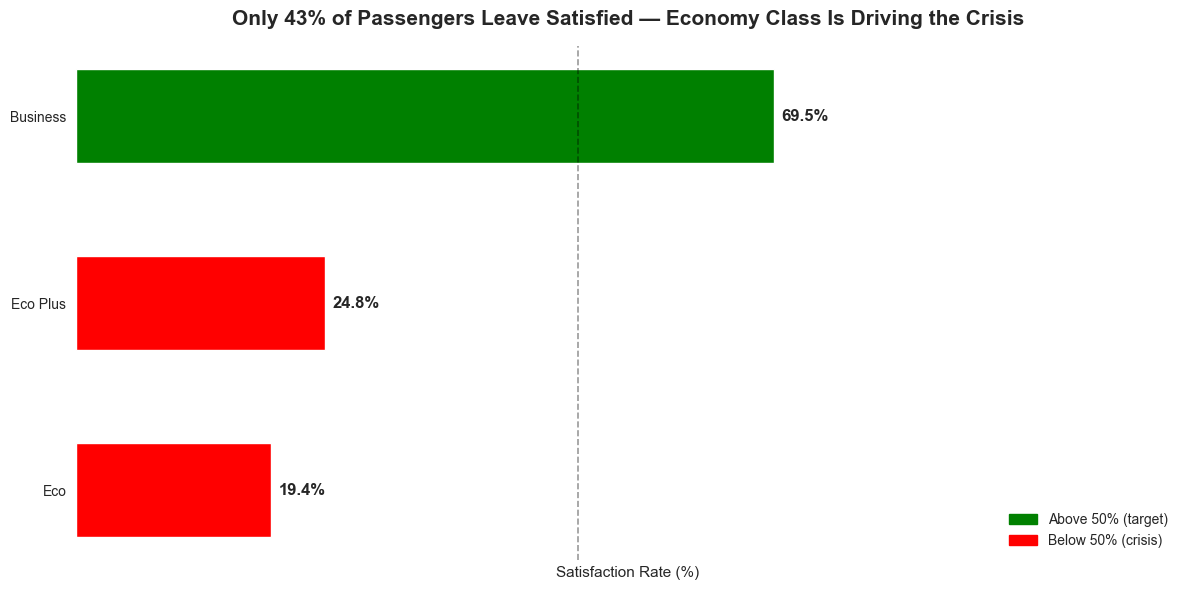

In [7]:
sat_by_class = df.groupby('Class')['satisfaction_binary'].mean().sort_values() * 100
sns.set_style("white")
fig, ax = plt.subplots(figsize=(12, 6))
colors = ['green' if v >= 50 else 'red' for v in sat_by_class.values]
bars = ax.barh(sat_by_class.index, sat_by_class.values, color=colors, height=0.5)
ax.axvline(50, color='black', linestyle='--', alpha=0.4, linewidth=1.2, label='50% threshold')
for bar, val in zip(bars, sat_by_class.values):
    ax.text(val + 0.8, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=12, fontweight='bold')
ax.set_title('Only 43% of Passengers Leave Satisfied — Economy Class Is Driving the Crisis',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Satisfaction Rate (%)', fontsize=11)
ax.set_xlim(0, 110)
ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
ax.tick_params(left=False, bottom=False)
ax.set_xticks([])
legend_patches = [mpatches.Patch(color='green', label='Above 50% (target)'),
                  mpatches.Patch(color='red', label='Below 50% (crisis)')]
ax.legend(handles=legend_patches, loc='lower right', frameon=False)
plt.tight_layout()
plt.show()

**Story — Setup → Conflict → Resolution**

**Setup:** One aircraft, one operational team, and three fare classes make up the setup. It is assumed that all three would be about equally satisfied. It isn't.

**Conflict:** The business class appreciation is higher than 69%. The economy is below 20%. That is a sepration of strutures between front and rear of same aircraft, not a gap. It's hardly any better than Economy Plus.

**Resolution:** Nearly all of the 43% overall statistic can be attributed to economic issues. Any expenditure plan that disregards this and refines the business cabin is optimizing for the wrong kind of travelers. Economy is where the majority of disgruntled travelers reside, and that is where the funds ought to be allocated.

## Insight 2: The satisfaction Heatmap: Airline Class Completely Differentiates what promotes Happiness.

**Why this matters:** the whole picture is concealed by a single average rating. This heatmap displays the facilities that most clearly distinguish between passenger who enjoy themselves and those who are not, as well as whether this varies by class. It does, quite significantly.

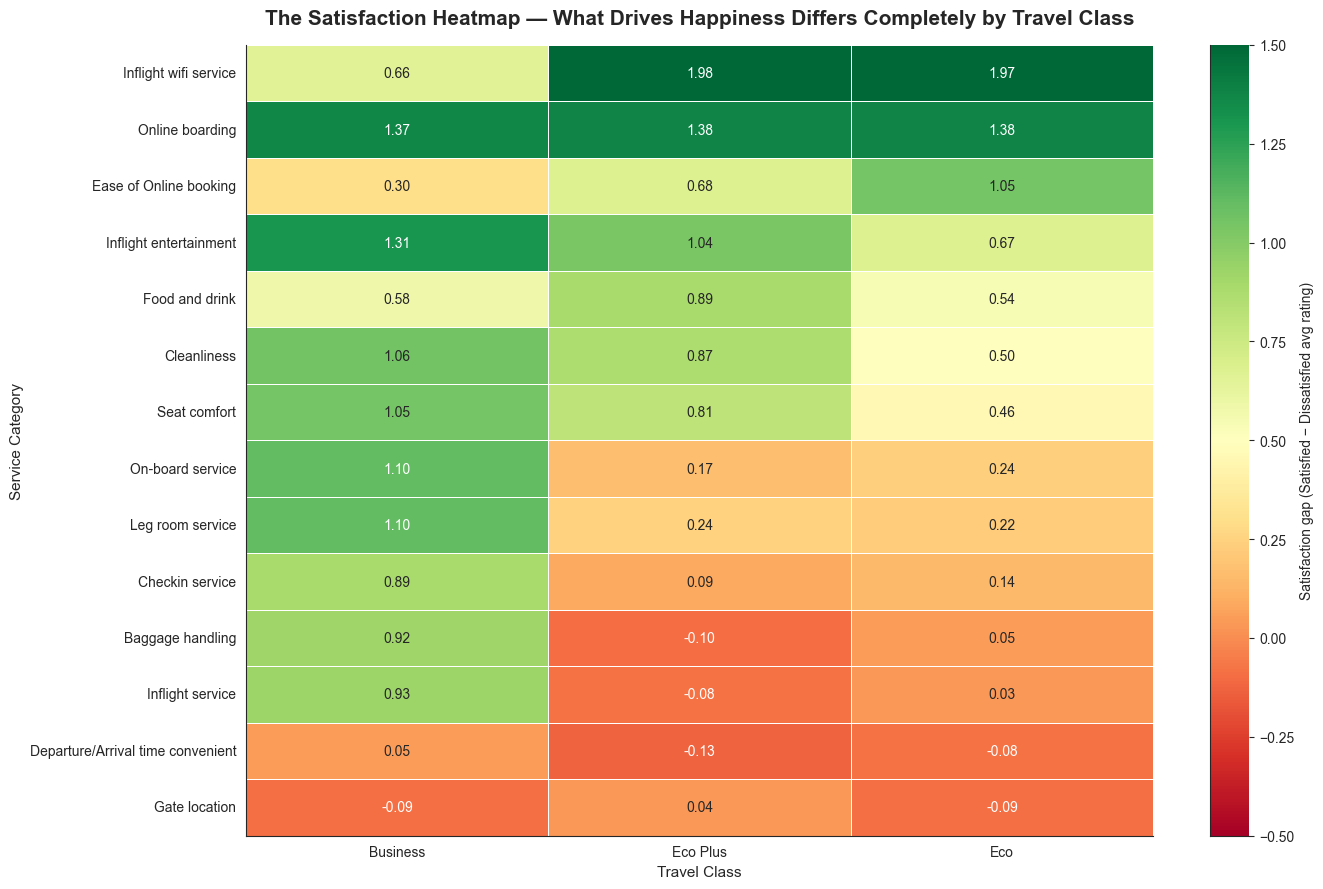

In [8]:
sns.set_style("white")
gap_data = {}
for cls in ['Business', 'Eco Plus', 'Eco']:
    satisfied = df[(df['Class'] == cls) & (df['satisfaction'] == 'satisfied')][rating_cols].mean()
    dissatisfied = df[(df['Class'] == cls) & (df['satisfaction'] == 'neutral or dissatisfied')][rating_cols].mean()
    gap_data[cls] = satisfied - dissatisfied

gap_df = pd.DataFrame(gap_data)
gap_df = gap_df.sort_values('Eco', ascending=False)

fig, ax = plt.subplots(figsize=(14, 9))
sns.heatmap(gap_df, cmap='RdYlGn', annot=True, fmt='.2f', linewidths=0.5,
            ax=ax, cbar_kws={'label': 'Satisfaction gap (Satisfied − Dissatisfied avg rating)'},
            vmin=-0.5, vmax=1.5)
ax.set_title('The Satisfaction Heatmap — What Drives Happiness Differs Completely by Travel Class',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Travel Class', fontsize=11)
ax.set_ylabel('Service Category', fontsize=11)
ax.tick_params(left=False, bottom=False)
sns.despine()
plt.tight_layout()
plt.show()

**Story — Setup → Conflict → Resolution**

**Setup:** It is difficult to quickly scan a table with 42 numbers, which include 14 operations spread over three classes. The treand is right away thanks to the heatmap.

**Conflict:** Different classes have different motivators for satisfication. WIFI and  online boarding exhibit the biggest disparities in Economy. Onboard service and in-flight entirenment are increasingly important in business. For business travelers, single company-wide wifi solution would be completely ineffective.

**Resolution:** Investments need to be divided into classes. Digital services must be fixed for the economy. Businesses require an enhanced premium in-cabin experience. Every passenger will be equally disappointed if they are all treated similarly.

> *Note: Here, a heatmap has been used based on the foundation that it is perfect for combining visual caues and details at the same time(Week 3, M512 course notes).*

## Insight 3: The 20-Minute Rule indicates that while passengers are following of short delays, after every 20 minute costs them money.

**Why this matters:** After a certain amount of delay, pleasure drastically decreases. The airline should adjust its operational KPIs in light of this 
objective.

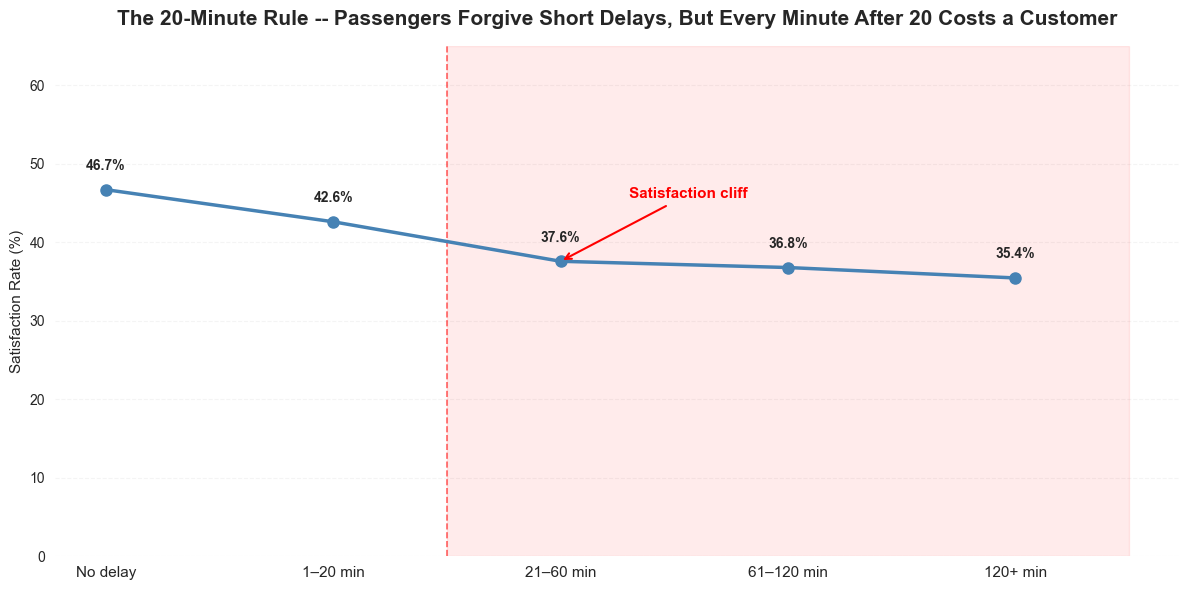

In [9]:
sat_by_delay = df.groupby('delay_bucket', observed=True)['satisfaction_binary'].mean() * 100
fig, ax = plt.subplots(figsize=(12, 6))
x_vals = range(len(sat_by_delay))
ax.plot(x_vals, sat_by_delay.values, marker='o', markersize=8,
        color='steelblue', linewidth=2.5, zorder=3)
ax.axvspan(1.5, len(sat_by_delay) - 0.5, alpha=0.08, color='red', zorder=1)
ax.annotate('Satisfaction cliff',
            xy=(2, sat_by_delay.iloc[2]),
            xytext=(2.3, sat_by_delay.iloc[2] + 8),
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
            fontsize=11, color='red', fontweight='bold')
ax.axvline(1.5, color='red', linestyle='--', alpha=0.6, linewidth=1.2)
for x, (label, val) in enumerate(sat_by_delay.items()):
    ax.text(x, val + 2.5, f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_xticks(x_vals)
ax.set_xticklabels(sat_by_delay.index, fontsize=11)
ax.set_title('The 20-Minute Rule -- Passengers Forgive Short Delays, But Every Minute After 20 Costs a Customer',
             fontsize=15, fontweight='bold', pad=15)
ax.set_ylabel('Satisfaction Rate (%)', fontsize=11)
ax.set_ylim(0, 65)
ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
ax.grid(axis='y', alpha=0.2, linestyle='--')
plt.tight_layout()
plt.show()

**Story — Setup → Conflict → Resolution**

For a valid reason, airline make significant investments in punctuality. However the typical industry metric-the proportion of flights that are delayed by more than 15 minutes-might not be the best way to comprehend  *passenger experience* of delay.

**Setup:** Anything changes at twenty one minutes. Satisfication drops rapidly and steeply from a cliff. The passenger relatioship is seriously harmed by the 60 minute point. The decline is a step change rather than gradual one

**Conflict:** At 21 minutes, everything changes. Satisfaction falls off a cliff — steeply and quickly. By the 60-minute mark, the damage to the passenger relationship is severe. The drop is not gradual; it is a step change.

**Resolution:** The operational KPI for the airline should be **keep delays below 20 minutes** rather than "eliminate all delays". Satisfication is significantly preserved when a 45-minute delay is reduced to 18 minutes. the needle hardly moves when it is shortened to 22 m inutes. That is an aim that is clear, attainable, supported by facts, and much more intelligent use of operating sources.

## Insight 4: The airline's golden spot is between the edges of 40 and 60; under 30's are hotspot for displeasure that the industry cannot ignore.

**Why this matters:** This is important because, according to aviation demographic trends, younger travelers will likely account for a long portion of future earnings. Long-term customer relationship strategy requires a knowledge of how satisfication varies by age, with under 30's now being among the most dissatisfied generation.

In [10]:
satisfied_ages = df[df['satisfaction'] == 'satisfied']['Age']
dissatisfied_ages = df[df['satisfaction'] == 'neutral or dissatisfied']['Age']
fig = go.Figure()
fig.add_trace(go.Violin(
    y=satisfied_ages,
    name='Satisfied',
    box_visible=True,
    meanline_visible=True,
    fillcolor='teal',
    line_color='teal',
    opacity=0.7,
    hoverinfo='y+name'
))
fig.add_trace(go.Violin(
    y=dissatisfied_ages,
    name='Neutral / Dissatisfied',
    box_visible=True,
    meanline_visible=True,
    fillcolor='red',
    line_color='red',
    opacity=0.7,
    hoverinfo='y+name'
))
fig.update_layout(
    title=dict(text="Age 40-60 Are the Airline's Sweet Spot -- Under-30s Are a Dissatisfaction Hotspot",
               font=dict(size=15)),
    yaxis_title='Passenger Age',
    plot_bgcolor='white',
    paper_bgcolor='white',
    violingap=0.3,
    violinmode='group',
    showlegend=True,
    yaxis=dict(showgrid=False, zeroline=False),
    xaxis=dict(showgrid=False)
)
fig.show(renderer="notebook_connected")

**Story — Setup → Conflict → Resolution**

**Setup:** Because it shows the entire contour of the age range across both happy groups rather than just the average, a vilion chart is employed in this instance. The story resides in that shape.

**Conflict:** Passengers in the 40-60 age range seem to be the most satisfied. Passengers that are dissatisfied tend to be younger, with the heaviest mass being under 30. The most disgruntled customers of the aviation are digital natives, who grew up with frictuionless application-based everything.

**Resolution:** This has a direct connection to insight 2. Young travellers are not happy with food or legroom; rather, they are unhappy with inadequate internet because quick communication is a necessity for them rather than a benifit. In ten years, business travel will be dominated by people in their 30s and 40s. Alienating them today is a future income crisis rather than an immediate issue.

## Insight 5: why Leisure Travelers in Business Class are the most Disappointed:- paying Premium, Feeling Cheated.

**Why this matters:** The reason this is important is that trip goal and class interact ways that are hidden by aggregation analysis. The data indicates that leisure travelers in the business class are the most unsatisfied subgroup, indicating a mismatch between expectations and delivery. This is because their expectation are fundamentally different from those of frequent business travelers.

In [11]:
sat_cross = df.groupby(['Class', 'Type of Travel'])['satisfaction_binary'].mean() * 100
sat_cross = sat_cross.reset_index()
sat_cross.columns = ['Class', 'Type of Travel', 'Satisfaction Rate']
travel_types = sat_cross['Type of Travel'].unique()
colors_travel = {'Business travel': 'steelblue', 'Personal Travel': 'darkorange'}
fig = go.Figure()
for tt in travel_types:
    subset = sat_cross[sat_cross['Type of Travel'] == tt]
    fig.add_trace(go.Bar(
        x=subset['Class'],
        y=subset['Satisfaction Rate'],
        name=tt,
        marker_color=colors_travel.get(tt, 'lightgray'),
        text=[f'{v:.1f}%' for v in subset['Satisfaction Rate']],
        textposition='outside',
        hovertemplate='Class: %{x}<br>Satisfaction: %{y:.1f}%<br>Travel type: ' + tt + '<extra></extra>'
    ))
fig.update_layout(
    barmode='group',
    title=dict(text='Paying Premium, Feeling Cheated -- Why Leisure Travellers in Business Class Are the Most Disappointed',
               font=dict(size=15)),
    yaxis_title='Satisfaction Rate (%)',
    xaxis_title='Travel Class',
    plot_bgcolor='white',
    paper_bgcolor='white',
    yaxis=dict(showgrid=False, zeroline=False, range=[0, 105]),
    xaxis=dict(showgrid=False),
    legend_title_text='Travel Purpose'
)
fig.show(renderer="notebook_connected")


**Story — Setup → Conflict → Resolution**

Different expectations, same seat. A regular business traveler and a pleasure traveler in business class have same seats, but their expectations are quite different. The data demonstrates how important differentiation is.

**Setup:** The graph shows how satisfication varies across three different passenger subgroups by cross tabulating class with travel goal.

**Conflict:** Out of all the subgroups in the sample, business class leisure travelers are the least satisfied. They landed with lofty expectations and paid more severe than it would be for a road warrior who has gradually decreased their demands when the seat is outdated, the food is disappointing or the wifi malfunctions.

**Resolution:** The most deterimental combine for the customer experience is premium pricing plus unfulfilled expectations. The airline must either cease offering leisure travelers upgrading dreams it cannot yet fulfill or enhance the business goods to meet what the price tag promise.

## Insight 6: The Airline is investing in the wrong upgrades because seat comfort and legroom are more important than food and Wi-Fi.

**Why this matters:** Particularly in the Economy class, not every service upgrade is worth the same amount. Physical comfort is the main factor, surpassing digital services or food, according to this diverging bar chart, which seprates the services that most strongly distinguish satisfied from unsatisfied Economy customers.

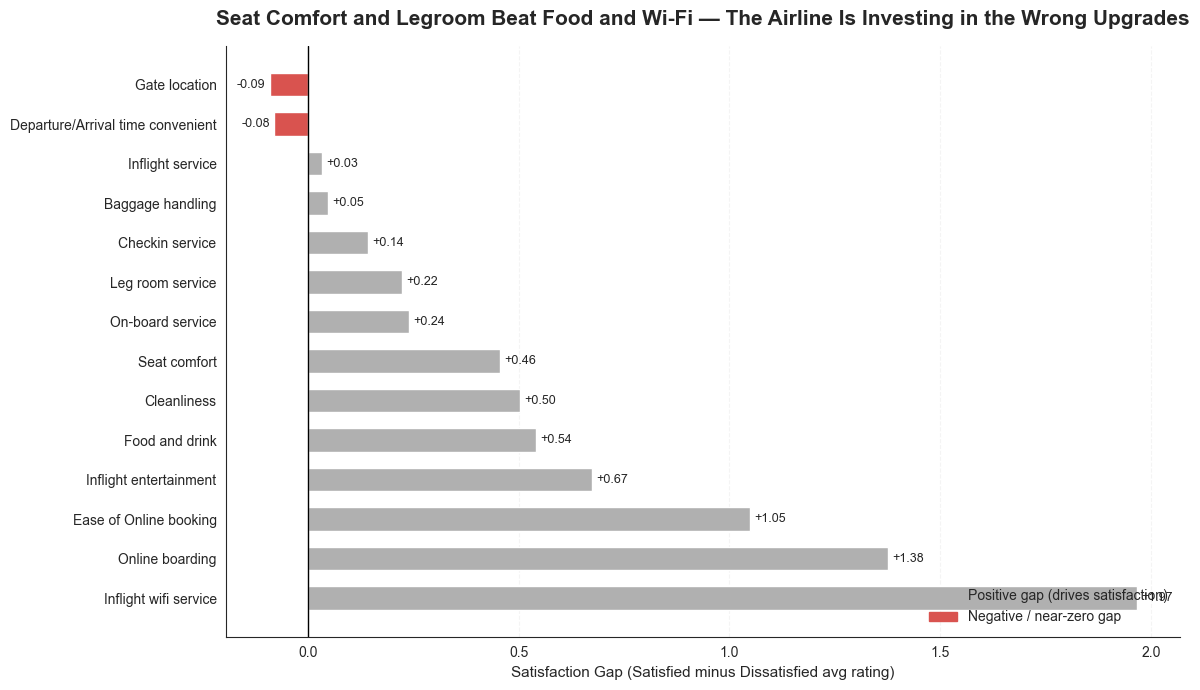

In [12]:
sns.set_style("white")
eco = df[df['Class'] == 'Eco']
sat_eco = eco[eco['satisfaction'] == 'satisfied'][rating_cols].mean()
dis_eco = eco[eco['satisfaction'] == 'neutral or dissatisfied'][rating_cols].mean()
gap_eco = (sat_eco - dis_eco).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(12, 7))
colors = ['#b0b0b0' if v >= 0 else '#d9534f' for v in gap_eco.values]
bars = ax.barh(gap_eco.index, gap_eco.values, color=colors, height=0.6)
ax.axvline(0, color='black', linewidth=1)
for bar, val in zip(bars, gap_eco.values):
    xpos = val + 0.01 if val >= 0 else val - 0.01
    ha = 'left' if val >= 0 else 'right'
    ax.text(xpos, bar.get_y() + bar.get_height() / 2,
            f'{val:+.2f}', va='center', ha=ha, fontsize=9)
ax.set_title('Seat Comfort and Legroom Beat Food and Wi-Fi — The Airline Is Investing in the Wrong Upgrades',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Satisfaction Gap (Satisfied minus Dissatisfied avg rating)', fontsize=11)
ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
ax.tick_params(left=False, bottom=False)
ax.grid(axis='x', alpha=0.2, linestyle='--')
grey_patch = mpatches.Patch(color='#b0b0b0', label='Positive gap (drives satisfaction)')
red_patch = mpatches.Patch(color='#d9534f', label='Negative / near-zero gap')
ax.legend(handles=[grey_patch, red_patch], loc='lower right', frameon=False)
sns.despine()
plt.tight_layout()
plt.savefig('insight9.png', dpi=150, bbox_inches='tight')
plt.show()

**Story — Setup → Conflict → Resolution**

**Setup:** The graph calculates the "satisfaction gap" for each Economy service, or the average rating difference between passengers who are happy and those who are not. The services's ability to distinguish between satisfied and dissatisfied customers increases with the size of the bar.

**Conflict:** It's evident from the numbers. The amenities that most significantly seprate happy from unhappy Economy travelers are in flight internet (+1.97), online boarding(+1.38), and convenience of booking(+1.05). Legroom (+0.22) and seat comfort(+0.46) are in the middle. Dissatisfied passengers rank gate location(-0.09) and departure timing(-0.08) same or higher, making them pratically meaningless.

**Resolution:** In Economy, the airline's largest levers for customer happiness are digital rather than physical. Gaps in WiFi and online boarding are over times greater than those in seat comfort. According to the research, investing in digital service quality is the sole most significant action for Economical customers, thus it is not a desirable.

## Insight 7: High Ratings ≠ High Impact — The Services That Matter Most Are Not the Ones Passengers Rate Highest

**Why this matters:** A significant effect does not equate to high grade. This scatter plot shows which services travelers rank highly but hardly notice when they are upgraded, as well as which offerings actually drive satisfied outcomes.

In [13]:
avg_ratings = df[rating_cols].mean()
correlations = df[rating_cols].corrwith(df['satisfaction_binary'])
scatter_df = pd.DataFrame({'avg_rating': avg_ratings, 'correlation': correlations,
                            'service': avg_ratings.index}).reset_index(drop=True)
mean_rating = scatter_df['avg_rating'].mean()
mean_corr = scatter_df['correlation'].mean()
text_positions = {
    'Inflight wifi service': 'middle right',
    'Online boarding': 'top center',
    'Inflight entertainment': 'top center',
    'Seat comfort': 'top right',
    'Cleanliness': 'bottom left',
    'Leg room service': 'bottom center',
    'On-board service': 'top left',
    'Food and drink': 'bottom center',
    'Checkin service': 'bottom right',
    'Baggage handling': 'bottom left',
    'Inflight service': 'bottom right',
    'Ease of Online booking': 'bottom right',
    'Gate location': 'bottom right',
    'Departure/Arrival time convenient': 'bottom center',
}
positions = [text_positions.get(s, 'top center') for s in scatter_df['service']]
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=scatter_df['avg_rating'],
    y=scatter_df['correlation'],
    mode='markers+text',
    marker=dict(size=12, color='#378ADD', opacity=0.8),
    text=scatter_df['service'],
    textposition=positions,
    textfont=dict(size=9),
    hovertemplate='<b>%{text}</b><br>Avg Rating: %{x:.2f}<br>Correlation: %{y:.3f}<extra></extra>'
))
fig.add_hline(y=mean_corr, line_dash='dot', line_color='grey', opacity=0.6)
fig.add_vline(x=mean_rating, line_dash='dot', line_color='grey', opacity=0.6)
annotations = [
    dict(x=scatter_df['avg_rating'].max() - 0.05, y=scatter_df['correlation'].max() - 0.005,
         text='High rating, High impact', showarrow=False, font=dict(size=9, color='#555')),
    dict(x=scatter_df['avg_rating'].min() + 0.05, y=scatter_df['correlation'].max() - 0.005,
         text='Low rating, High impact', showarrow=False, font=dict(size=9, color='#d9534f')),
    dict(x=scatter_df['avg_rating'].max() - 0.05, y=scatter_df['correlation'].min() + 0.005,
         text='High rating, Low impact', showarrow=False, font=dict(size=9, color='#555')),
    dict(x=scatter_df['avg_rating'].min() + 0.05, y=scatter_df['correlation'].min() + 0.005,
         text='Low rating, Low impact', showarrow=False, font=dict(size=9, color='#555')),
]
fig.update_layout(
    title=dict(text='High Ratings != High Impact -- The Services That Matter Most Are Not Always the Highest Rated',
               font=dict(size=15)),
    xaxis_title='Average Passenger Rating (1-5)',
    yaxis_title='Correlation with Satisfaction',
    plot_bgcolor='white',
    paper_bgcolor='white',
    xaxis=dict(showgrid=False),
    yaxis=dict(showgrid=False),
    annotations=annotations,
    showlegend=False,
    height=550,
    margin=dict(l=60, r=60, t=80, b=60)
)
fig.show(renderer="notebook_connected")

**Story — Setup → Conflict → Resolution**

High effect may not equate to high ratings. Because the airline is making expenditure choices based solely on customer rating rather than determining which amenities actually promote satisfaction outcomes, it may be safeguarding the wrong services and solving wrong issues.

**Setup:** The x-axis of this scatter diagram shows passengers rank each of the 14 services, while the y-axis shows how much they influence overall satisfication. Every service's actual position is shown in four quadrants.

**Conflict:** A glaring discrepancy is revealed by the numbers. Despite having the lowest rating of any service (2.81 out of 5), in-flight wifi is in the high impact quadrant with correlation of 0.40 with satisfaction. Despite having a low average rating, online boarding correlates significantly higher at 0.55 Baggage handeling and in flight service, on the other hand, are scored over 3.6 but correlate below 0.25, placing them in the bottom-right. This indicates that although passengers give them high ratings, further improvemnts would hardly affect their level of pleasure.

**Resolution:** These days, the financial rationale is data-precise. priortize fixing the low-rated, high-impact wifi and online boarding. Defend but avoid oversepnding on in flight amenities and baggage handling-highly regarded, minimal impact. The quadrant structure completely eliminates uncertainty in budget allocation.

## Insight 8: The Premium Gap Is Closing on Physical Comfort Business Class Pays More But Feels Less.

**Why this matters:** The air carrier makes the most money per seat in business class. Passengers paying a premium are not receiving superior service if the comfot difference between Business and Economy is shrinking, which poses a direct threat to the pricing structure.

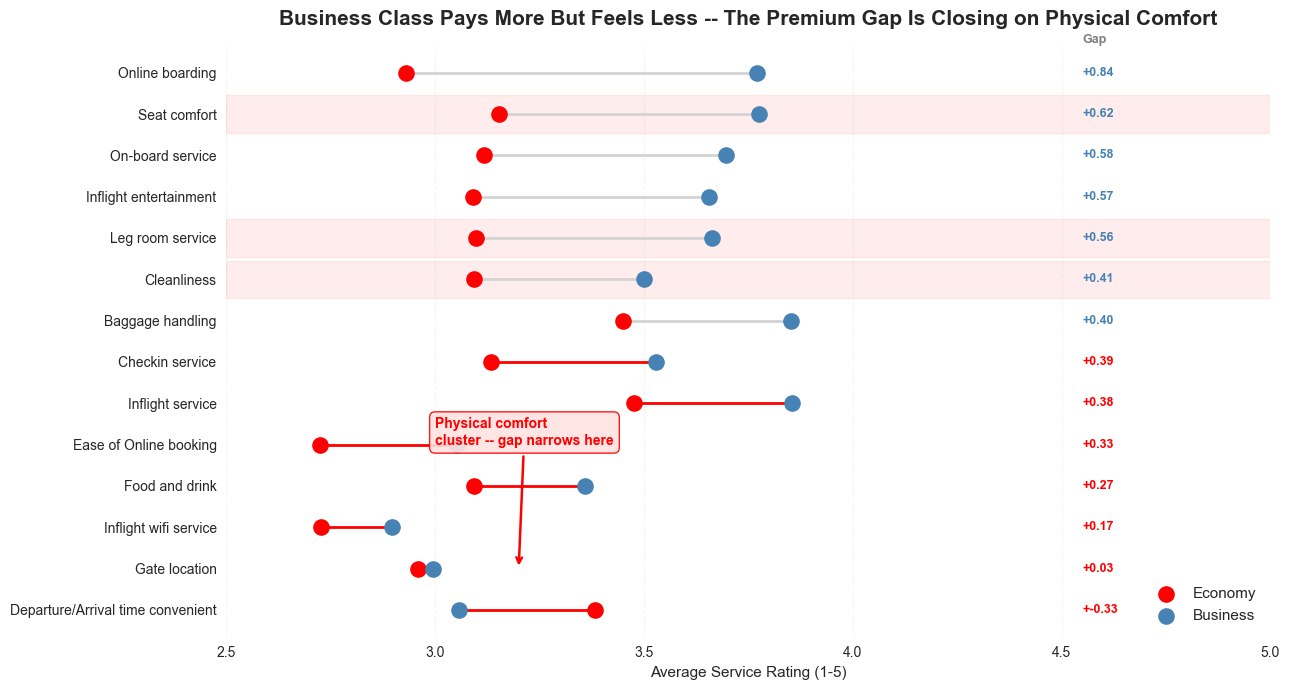

In [14]:
fig, ax = plt.subplots(figsize=(13, 7))
class_ratings = df.groupby('Class')[rating_cols].mean()
gap = class_ratings.loc['Business'] - class_ratings.loc['Eco']
gap_sorted = gap.sort_values(ascending=True)
sorted_cols = gap_sorted.index.tolist()
business_vals = class_ratings.loc['Business'][sorted_cols].values
eco_vals = class_ratings.loc['Eco'][sorted_cols].values
y_pos = np.arange(len(sorted_cols))

for i, (b, e) in enumerate(zip(business_vals, eco_vals)):
    color = 'red' if gap_sorted.iloc[i] < 0.4 else 'lightgray'
    ax.plot([e, b], [i, i], color=color, linewidth=2, zorder=2)

ax.scatter(eco_vals, y_pos, color='red', s=120, zorder=3, label='Economy')
ax.scatter(business_vals, y_pos, color='steelblue', s=120, zorder=3, label='Business')

comfort_services = ['Seat comfort', 'Leg room service', 'Cleanliness']
for i, col in enumerate(sorted_cols):
    if col in comfort_services:
        ax.axhspan(i - 0.45, i + 0.45, alpha=0.07, color='red', zorder=1)

for i, g in enumerate(gap_sorted.values):
    ax.text(4.55, i, f'+{g:.2f}', fontsize=9,
            color='steelblue' if g >= 0.4 else 'red',
            va='center', fontweight='bold')

ax.text(4.55, len(sorted_cols) - 0.2, 'Gap', fontsize=9,
        color='gray', va='center', fontweight='bold')
ax.set_yticks(y_pos)
ax.set_yticklabels(sorted_cols, fontsize=10)
ax.set_xlabel('Average Service Rating (1-5)', fontsize=11)
ax.set_xlim(2.5, 5.0)
ax.set_title("Business Class Pays More But Feels Less -- The Premium Gap Is Closing on Physical Comfort",
             fontsize=15, fontweight='bold', pad=15)
ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
ax.grid(axis='x', alpha=0.2, linestyle='--')
ax.legend(frameon=False, fontsize=11, loc='lower right')
ax.annotate('Physical comfort\ncluster -- gap narrows here',
            xy=(3.2, 1),
            xytext=(3.0, 4),
            arrowprops=dict(arrowstyle='->', color='red', lw=1.8),
            fontsize=10, color='red', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='mistyrose',
                      edgecolor='red', alpha=0.9))
plt.tight_layout()
plt.savefig('insight11.png', dpi=150, bbox_inches='tight')
plt.show()

**Story — Setup → Conflict → Resolution**

**Setup:** A single service is represented by each pair of dots. The difference between them is depicted by the line; a longer line indicates that business performs better than the economy. A shorter line indicates that the premium is vanishing.

**Conflict:** Depending on the provider, the gap tells two very different stories. There are long waits for digital services like in-flight entertainment and online boarding. Clearly, business class is in the lead. the bodily comfort cluster, however, presents a different picture. The chart's tightest gaps, indicated in red, are found in seat comfort, legroom, and cleanliness. The seat seems only slightly better for  atraveler who pays three times the economy rate.
**Resolution:** Instead of the one thing that travelers experience throughout the entire flight-physical comfort-the premium is maintained through screens and food. That is not a posture that can be sustained. Refurbishing the seats and interior is the minimum amount needed to justify the cost; It is not luxury upgrade.

## Insight 9: Service Clusters Revealed — Fix Seat Comfort and You Lift Three Scores at Once

**Why this matters:** Improving the Airline services requires costly and time-consuming capital investment. A stronger ROI argument to the finance team and more intelligent resource allocation are made possible by determining which service enhancements have favorable knock-on impacts on associated service perceptions - a "One investement, multiple wins" rationale.

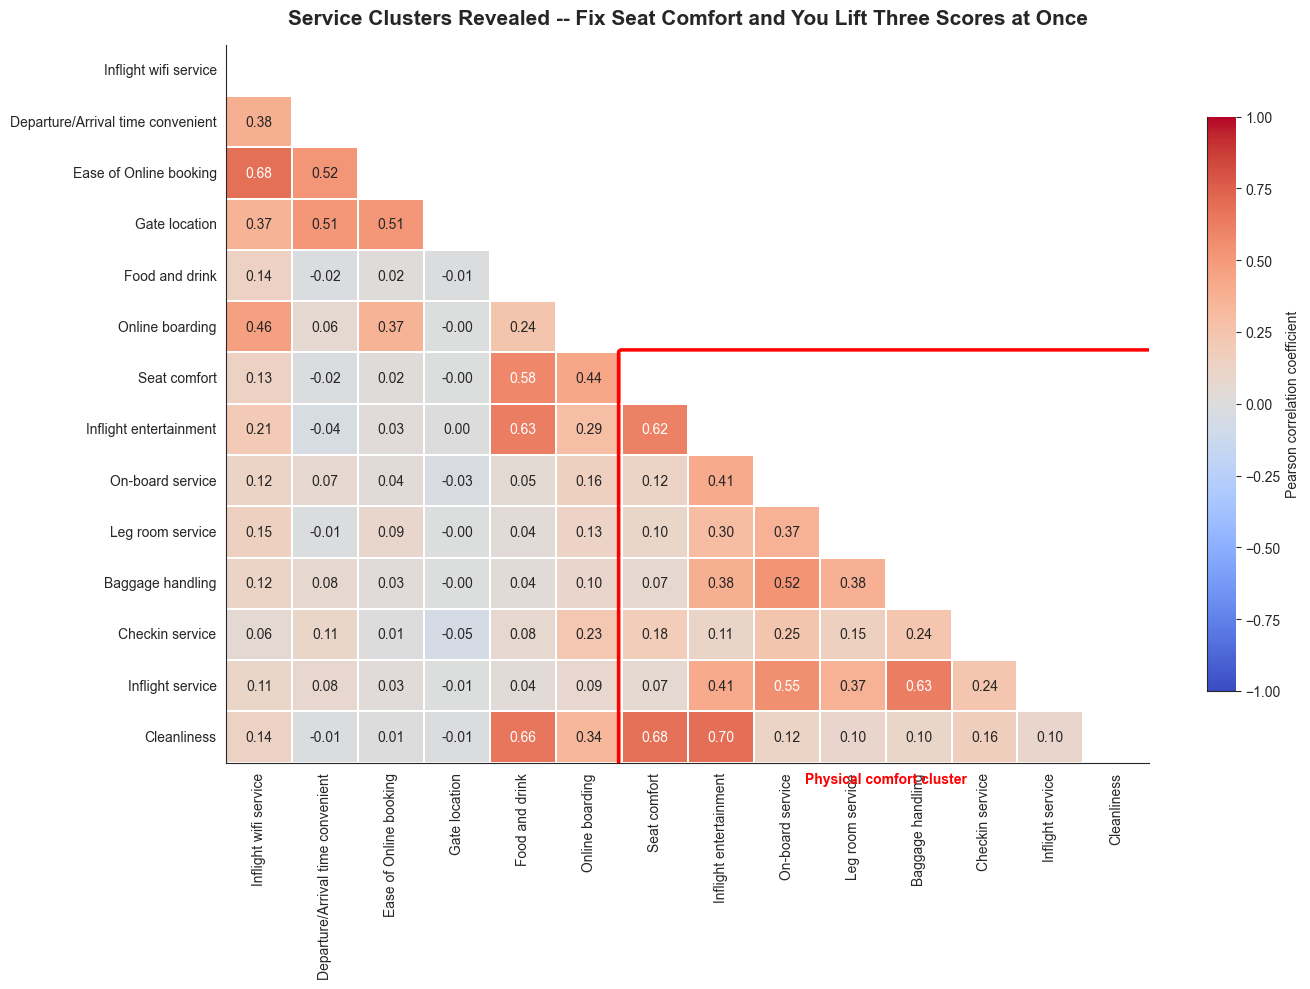

In [15]:
sns.set_style("white")
corr = df[rating_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr, mask=mask, cmap='coolwarm', annot=True, fmt='.2f',
            vmin=-1, vmax=1, linewidths=0.3, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Pearson correlation coefficient'})
ax.set_title('Service Clusters Revealed -- Fix Seat Comfort and You Lift Three Scores at Once',
             fontsize=15, fontweight='bold', pad=15)
ax.tick_params(left=False, bottom=False)

comfort_cols = ['Seat comfort', 'Leg room service', 'Cleanliness']
col_list = list(corr.columns)
idxs = [col_list.index(c) for c in comfort_cols if c in col_list]
if len(idxs) >= 2:
    min_idx = min(idxs)
    max_idx = max(idxs)
    rect = mpatches.FancyBboxPatch(
        (min_idx, min_idx), max_idx - min_idx + 1, max_idx - min_idx + 1,
        boxstyle="round,pad=0.05", linewidth=2.5,
        edgecolor='red', facecolor='none', zorder=5
    )
    ax.add_patch(rect)
    ax.text(min_idx + (max_idx - min_idx + 1) / 2, max_idx + 1.4,
            'Physical comfort cluster', ha='center', fontsize=10,
            color='red', fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

**Story — Setup → Conflict → Resolution**

There are 91 distinct pairwise correlation values in a single correlation heatmap spanning all fourteen service rating columns, which is much too many to take in from table. The complexity is transformed into a pattern that mnay be understood in a matter of seconds through visual encoding.

**Setup:** In this case heatmap is selected since it quickly identifies trends across 14 services, while table of information would be hard to comprehend

**Conflict:** The fourteen services are not independent of one another. the close cluster of legroom, cleanliness, amd seat comfort is highlighted by red box.

**Resolution:** A sigle seat repair procedure togeather raises all three scores. Additionally a physically renovated cabin appears more spacious and organized. This one investment tghree improvements logis suggests that the dataset's primary ROI objective is physiological pleasure.

> *Note: Because heatmaps are perfect for "mixing detail and visual cues"—the correlation matrix is best comprehended visually rather than as a table of numbers—a second heatmap is employed in this instance.*

## Section 5: Final Discussion & Conclusion

### Conclusion

The data unequivocally demonstrates that the airline's displeasure crisis is centered on economic concerns, caused by poor digital offers and declining physical comfort and its most acute among younger, loyal customers who have highest long-term economic worth

The three expenses that will have the most effects are repariring economy wifi, reducing delays to less than twenty minutes, and updating economy seating. The evidence is undeniable. decision-making is now the responsibility of leadership board.

### Strengths of This Analytical Pipeline

- **Large dataset** 
- **Multi-dimensional** 
- **Clear outcome variable** 
- **Three visualisation libraries** 
- **Actionable structure** 

### Limitations

- **Self-selection bias** 
- **Cross-sectional data** 
- **No financial data**


### Future Work

- **Predictive model** 
- **Longitudinal data** 
- **NPS integration**
- **Financial modelling**
- **Segmented dashboards** 